VIC TRAFFIC - VIOLATION SYSTEM: ANALYSIS PIPELINE
[Execution Time: build_dataframe              0.021410 s]
[VALIDATION] Data validation successful: 51 records, 7 columns.
[Execution Time: validate_dataframe           0.009032 s]

--- First 5 records ---
Driver ID Violation Type  Fine Amount  Speed Over Limit  Number of Violations Payment Status  Violation Month
     D001       Speeding           67                30                     3         Unpaid                7
     D001        Parking          120                 0                     3           Paid                6
     D001    Signal Jump          300                 0                     3         Unpaid                3
     D002       Speeding          180                12                     2           Paid                2
     D002        Parking           80                 0                     2         Unpaid               12

--- Summary statistics ---
[Execution Time: summary_statistics           0.001671 s]

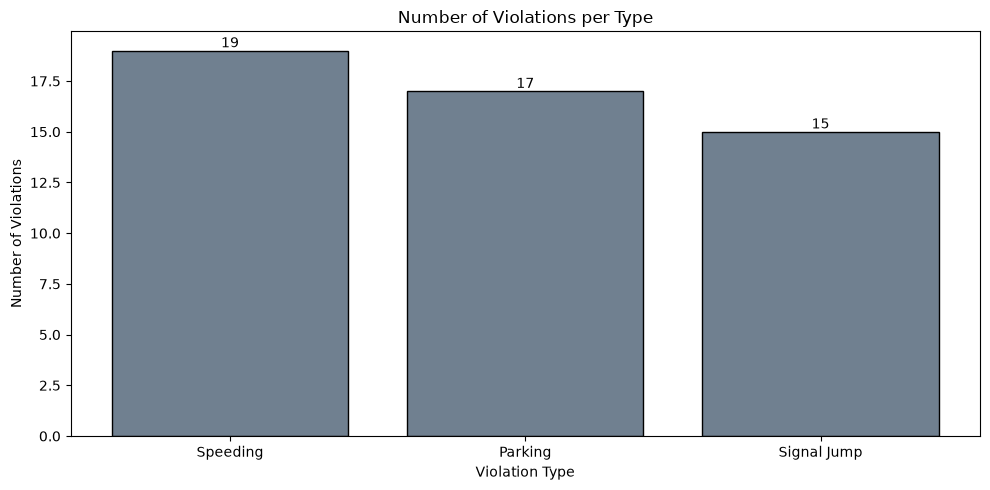

  saved -> graphs/violations_per_type.png
[Execution Time: violations_per_type          0.134441 s]


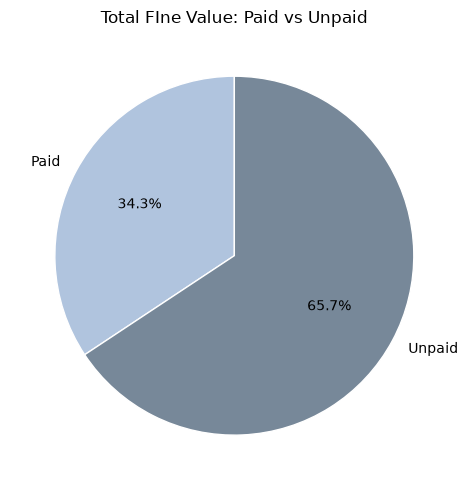

  saved -> graphs/payment_status.png
[Execution Time: payment_status               0.117885 s]


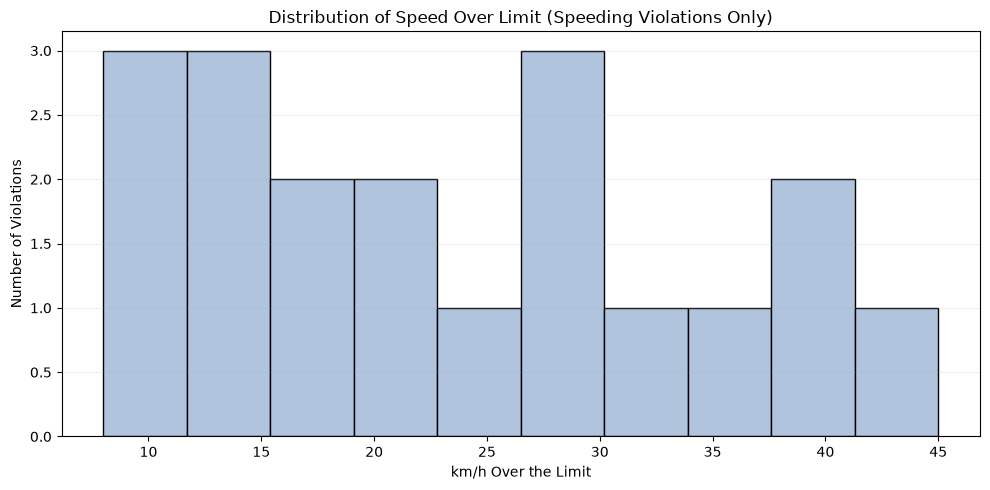

  saved -> graphs/speed_distribution.png
[Execution Time: speed_distribution           0.111340 s]


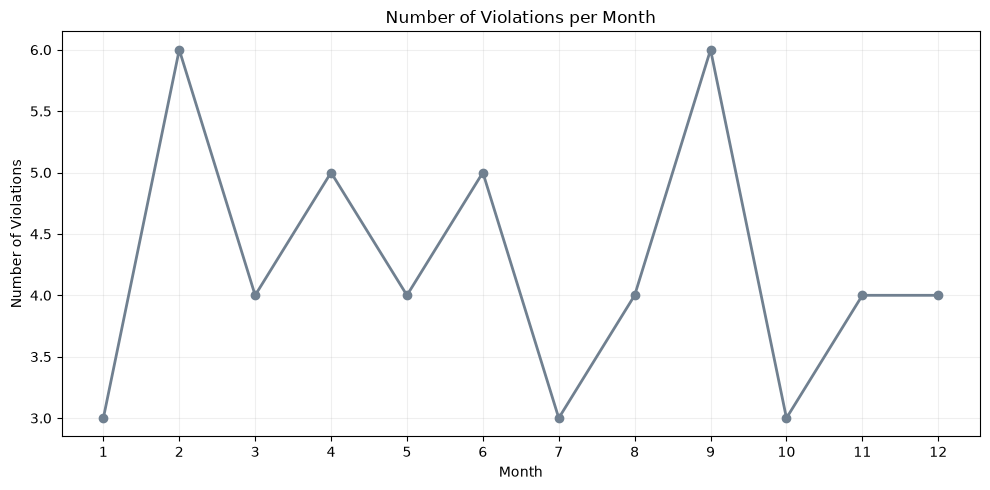

  saved -> graphs/violations_per_month.png
[Execution Time: violations_per_month         0.108231 s]


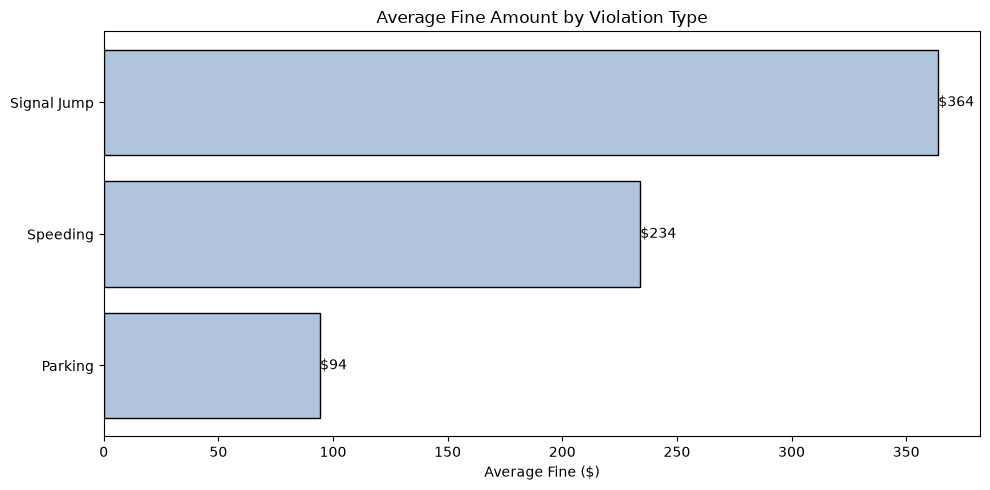

  saved -> graphs/average_fine_by_violation_type.png
[Execution Time: average_fine_by_violation_type 0.089046 s]

[Execution Time: run_analysis                 0.598702 s]


In [38]:
import time
from functools import wraps

import pandas as pd
import matplotlib.pyplot as plt

from classes import InvalidViolationDataError
from data import build_drivers_and_records

# 1. MEASURING THE EXECUTION TIME
def timed(func):
    """ Measures and prints the execution time of a function. """
    @wraps(func)
    def wrapper(*args, **kwargs):
        start_time = time.perf_counter() # this is used for measuring elapsed time: .perf_counter is Python's standard lib func
        result = func(*args, **kwargs)
        elapsed_time = time.perf_counter() - start_time
        print(f"[Execution Time: {func.__name__:<28} {elapsed_time:.6f} s]")
        return result
    return wrapper

# function above basically executes start time -> run function -> calculate elapsed time

# 2. DATA VALIDATION

REQUIRED_COLUMNS = [
    "Driver ID", "Violation Type", "Fine Amount", "Speed Over Limit", 
    "Number of Violations", "Payment Status", "Violation Month",
]

@timed
def validate_dataframe(df):
    """
        Validates the created DataFrame based on the assessment's data requirements.
        Raises an error if invalid data is found (InvalidViolationDataError).
    """
    missing_columns = [c for c in REQUIRED_COLUMNS if c not in df.columns]
    if missing_columns:
        raise InvalidViolationDataError(f"Missing required columns: {missing_columns}")

    if len(df) < 50:
        raise InvalidViolationDataError(f"Dataset has only {len(df)} records; the assessment brief requires at least 50 records.")

    if df["Fine Amount"].lt(0).any():
        raise InvalidViolationDataError("One or more fine amounts are found negative.")

    if df["Speed Over Limit"].lt(0).any():
        raise InvalidViolationDataError("One or more speed-over-limit values are found negative.")

    invalid_months = df.loc[~df["Violation Month"].between(1, 12), "Violation Month"]
    if not invalid_months.empty:
        raise InvalidViolationDataError(f"Invalid violation month(s): {invalid_months.tolist()}")

    invalid_status = set(df["Payment Status"].unique()) - {"Paid", "Unpaid"}
    if invalid_status:
        raise InvalidViolationDataError(f"Invalid payment status value(s): {invalid_status}")

    inconsistent_records = df[(df["Violation Type"] != "Speeding") & (df["Speed Over Limit"] != 0)]
    if not inconsistent_records.empty:
        raise InvalidViolationDataError(f"{len(inconsistent_records)} non-speeding record(s) have a non-zero speed over limit")

    print(f"[VALIDATION] Data validation successful: {len(df)} records, {len(df.columns)} columns.")
    return True

# 3. BUILDING THE DATAFRAME
@timed
def build_dataframe():
    """ Builds the records and converts them into a Pandas DataFrame. """
    try:
        drivers, records = build_drivers_and_records()
    except Exception as error:
        raise InvalidViolationDataError(f"Unable to build records: {error}")

    df = pd.DataFrame(records)
    # Keep only the required columns in the required order based on assessment brief
    df = df[[c for c in REQUIRED_COLUMNS if c in df.columns]]
    return df, drivers

# 4. DATA ANALYSIS
@timed
def summary_statistics(df):
    """Summary of the statistics in a descriptive way."""
    speeding_records = df[df["Speed Over Limit"] > 0]
    return {
        "Total number of records": len(df),
        "Unique drivers": df["Driver ID"].nunique(),
        "Total fines issued": round(df["Fine Amount"].sum(), 2),
        "Fines collected (Paid)": round(df.loc[df["Payment Status"] == "Paid", "Fine Amount"].sum(), 2),
        "Fines outstanding (Unpaid)": round(df.loc[df["Payment Status"] == "Unpaid", "Fine Amount"].sum(), 2),
        "Average fine": round(df["Fine Amount"].mean(), 2),
        "Most common violation": df["Violation Type"].mode()[0],
        "Average speed over limit (speeding only)": round(speeding_records["Speed Over Limit"].mean(), 2),
        "Unpaid rate (%)": round((df["Payment Status"] == "Unpaid").mean() * 100, 1),
    }

@timed
def find_repeat_offenders(df, threshold=3):
    """Finds drivers with three or more violations."""
    violation_counts = df.groupby("Driver ID").size().sort_values(ascending=False)
    return violation_counts[violation_counts >= threshold]

# 5. CREATING THE MATPLOTLIB GRAPHS
# GRAPH FOR NUMBER OF VIOLATIONS PER TYPE
@timed
def violations_per_type(df, file_path="graphs/violations_per_type.png"):
    violation_counts = df["Violation Type"].value_counts()
    plt.figure(figsize=(10, 5))
    bars = plt.bar(violation_counts.index, violation_counts.values, color="slategray", edgecolor="black")
    plt.bar_label(bars)
    plt.title("Number of Violations per Type")
    plt.xlabel("Violation Type")
    plt.ylabel("Number of Violations")
    plt.tight_layout()
    plt.savefig(file_path, dpi=120)
    plt.show()
    plt.close()
    print(f"  saved -> {file_path}")

# GRAPH FOR PAYMENT STATUS: PAID VS UNPAID
@timed
def payment_status(df, file_path="graphs/payment_status.png"):
    fine_totals = df.groupby("Payment Status")["Fine Amount"].sum()
    plt.figure(figsize=(5, 5))
    plt.pie(fine_totals, labels=fine_totals.index, autopct="%1.1f%%", startangle=90, colors=["lightsteelblue", "lightslategrey"], wedgeprops={"edgecolor": "white"})
    plt.title("Total FIne Value: Paid vs Unpaid")
    plt.tight_layout()
    plt.savefig(file_path, dpi=120)
    plt.show()
    plt.close()
    print(f"  saved -> {file_path}")

# GRAPH FOR SPEED OVER LIMIT
@timed 
def speed_distribution(df, file_path="graphs/speed_distribution.png"):
    speeding_records = df[df["Speed Over Limit"] > 0]
    plt.figure(figsize=(10, 5))
    plt.hist(speeding_records["Speed Over Limit"], bins=10, color="lightsteelblue", edgecolor="black")
    plt.title("Distribution of Speed Over Limit (Speeding Violations Only)")
    plt.xlabel("km/h Over the Limit")
    plt.ylabel("Number of Violations")
    plt.grid(axis="y", alpha=0.2)
    plt.tight_layout()
    plt.savefig(file_path, dpi=120)
    plt.show()
    plt.close()
    print(f"  saved -> {file_path}")

# GRAPH FOR NUMBER OF VIOLATIONS PER MONTH
@timed
def violations_per_month(df, file_path="graphs/violations_per_month.png"):
    monthly_counts = df.groupby("Violation Month").size().reindex(range(1, 13), fill_value=0)
    plt.figure(figsize=(10, 5))
    plt.plot(monthly_counts.index, monthly_counts.values, marker="o", color="slategray", linewidth=2)
    plt.title("Number of Violations per Month")
    plt.xlabel("Month")
    plt.ylabel("Number of Violations")
    plt.xticks(range(1, 13))
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.savefig(file_path, dpi=120)
    plt.show()
    plt.close()
    print(f"  saved -> {file_path}")

# GRAPH FOR AVERAGE FINE AMOUNT BY VIOLATION TYPE
@timed
def average_fine_by_violation_type(df, file_path="graphs/average_fine_by_violation_type.png"):
    average_fines = df.groupby("Violation Type")["Fine Amount"].mean().sort_values()
    plt.figure(figsize=(10, 5))
    bars = plt.barh(average_fines.index, average_fines.values, color="lightsteelblue", edgecolor="black")
    plt.bar_label(bars, fmt="$%.0f")
    plt.title("Average Fine Amount by Violation Type")
    plt.xlabel("Average Fine ($)")
    plt.tight_layout()
    plt.savefig(file_path, dpi=120)
    plt.show()
    plt.close()
    print(f"  saved -> {file_path}")

# 6. MAIN PIPELINE
# TO DISPLAY TITLE IN TERMINAL
@timed
def run_analysis():
    print("=" * 65)
    print("VIC TRAFFIC - VIOLATION SYSTEM: ANALYSIS PIPELINE")
    print("=" * 65)

    try:
        df, drivers = build_dataframe()
        validate_dataframe(df)
    except InvalidViolationDataError as error:
        print(f"[ERROR] Pipeline stopped: {error}")
        return None

    print("\n--- First 5 records ---")
    print(df.head().to_string(index=False))

    print("\n--- Summary statistics ---")
    for key, value in summary_statistics(df).items():
        print(f"  {key:<40} {value}")

    print("\n--- Repeat offenders with 3+ violations ---")
    offenders = find_repeat_offenders(df)
    if offenders.empty:
        print(" None found.")
    else:
        for driver_id, violation_counts in offenders.items():
            print(f"  {driver_id}: {violation_counts} violations")

    print("\n Generating charts ---")
    violations_per_type(df)
    payment_status(df)
    speed_distribution(df)
    violations_per_month(df)
    average_fine_by_violation_type(df)

    print("\n" + "=" * 62)
    return df

if __name__ == "__main__":
    run_analysis()